# Arabic Stories - GPT Language Model from Scratch

Building a transformer based language model trained on Arabic short stories. The model goes through two stages: first learning general Arabic language patterns, then learning to follow story writing instructions.

Enable GPU before running: Runtime > Change runtime type > T4 GPU

In [ ]:
!cp -r /content/checkpoints /content/drive/MyDrive/
!cp -r /content/data /content/drive/MyDrive/
!cp -r /content/results /content/drive/MyDrive/

## Installing Dependencies

In [ ]:
!pip install torch torchvision torchaudio --quiet
!pip install transformers datasets tokenizers --quiet
!pip install matplotlib numpy tqdm --quiet
print('packages ready')

packages ready


## Imports

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import json
import math
import os
import time
import matplotlib.pyplot as plt

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('running on:', DEVICE)

torch.manual_seed(99)
np.random.seed(99)

running on: cuda


## Pretraining Data - Arabic Stories Corpus

In [ ]:
PRETRAIN_TEXT = """كان يا ما كان في قديم الزمان، في مملكة بعيدة تحيط بها الجبال الشامخة من كل جانب، ملك عادل يحكم شعبه بالحكمة والعدل. كان الناس في تلك المملكة يعيشون في سعادة وأمان، وكانت الأرض خصبة تمنح ثمارها بسخاء.
في يوم من الأيام، جاء إلى المملكة رجل غريب يحمل على ظهره حقيبة مليئة بالكتب والمخطوطات. وقف أمام بوابة القصر وطلب مقابلة الملك. أذن له الحرس بالدخول، فمثل الرجل أمام الملك وقال: يا مولاي، أنا حكيم متجول جبت البلاد وطفت الأمصار، وأحمل معي علوماً نفيسة وقصصاً عجيبة.
فرح الملك بالرجل وأمر بإكرامه وإنزاله في أفضل غرف القصر. وفي المساء، جلس الملك وحاشيته للاستماع إلى حكايات الرجل العجيب.
بدأ الحكيم يحكي: في بلاد ما بين النهرين، التقيت برجل عجوز يجلس تحت شجرة تين كبيرة. كان يتأمل في النجوم ويقرأ في الكتب. سألته: ماذا تقرأ يا شيخ؟ فأجابني بابتسامة حكيمة: أقرأ كتاب الكون يا بني، فكل نجمة هي كلمة وكل قمر هو سطر وكل شمس هي فصل من هذا الكتاب الكبير.
كانت المملكة تشتهر بتجارها الماهرين وصناعها الحاذقين. في السوق الكبير كانت البضائع تتنوع من الأقمشة الحريرية إلى التوابل العطرة ومن الأواني النحاسية إلى الأسلحة المطعمة بالفضة. وكان التجار يتبادلون البضائع بأمانة وصدق.
عاشت في تلك المدينة فتاة اسمها زينب كانت مشهورة بذكائها وحسن خلقها. تعلمت القراءة والكتابة في صغرها وكانت مولعة بالكتب والعلوم. قرأت كل الكتب التي في مكتبة والدها التاجر الغني وطلبت المزيد.
في صباح يوم ربيعي جميل، خرجت زينب إلى السوق برفقة خادمتها لشراء بعض الحاجيات. وبينما كانت تمشي بين دكاكين السوق، لفت نظرها دكان صغير يبيع الكتب والمخطوطات. دخلت لتنظر وإذا بالبائع يعرض عليها مخطوطة قديمة قائلاً هذه المخطوطة نادرة يا سيدتي وتحتوي على قصص وحكايات لم يسمع بها أحد.
في قرية صغيرة على ضفاف نهر عريض، عاش صياد اسمه حسن. كان حسن يخرج كل يوم مع الفجر في قاربه الصغير ليصطاد السمك. لم يكن غنياً لكنه كان راضياً قانعاً بما يرزقه الله.
ذات يوم، بينما كان حسن ينشر شباكه في الماء، لمح شيئاً لامعاً في قاع النهر. نزل إلى الماء وأحضر ذلك الشيء فإذا هو صندوق صغير مصنوع من الفضة مغلق بقفل ذهبي. حمل حسن الصندوق إلى البيت وأرى زوجته ما وجد.
قالت زوجته بدهشة: هذا كنز يا حسن ربما. لكن حسن الرجل الأمين قال: لا بد أن هناك صاحباً لهذا الصندوق فلنبحث عنه.
جاب حسن وزوجته القرى المجاورة يسألون عن صاحب الصندوق. وبعد أسبوع من البحث وجدا رجلاً شيخاً يبكي على فقدان صندوقه الذي سقط منه في النهر وهو يعبر في قاربه.
فرح الشيخ فرحاً عظيماً حين رأى صندوقه وقال لحسن: أنت رجل أمين يا بني والله سيجزيك خيراً. وفتح الصندوق وأعطى حسن نصف محتوياته وكانت تحتوي على عملات ذهبية ومجوهرات قيمة.
في زمن بعيد، كانت هناك مدينة تعرف بمدينة العلماء. كان فيها مئات المدارس والمكتبات وكان طلاب العلم يأتون إليها من كل أنحاء الدنيا. كان الحكام يكرمون العلماء ويقدرون العلم ويخصصون لهم الأموال الكافية للبحث والتدريس.
كان من أشهر علماء تلك المدينة رجل اسمه ابن الحكيم. درس الطب والرياضيات والفلك والفلسفة وكتب مئات الكتب. كان طلابه يأتون من كل بلاد الدنيا للتعلم منه.
قال ابن الحكيم يوماً لطلابه: العلم بحر واسع لا ساحل له والعمر قصير لا يكفي لاستيعاب كل ما فيه. لكن الواجب علينا أن نسبح في هذا البحر ما استطعنا وأن نعلم ما تعلمناه لمن يأتي بعدنا.
في يوم قائظ من أيام الصيف، كان قافلة من التجار تسير في الصحراء. كانوا يريدون الوصول إلى مدينة تبعد عنهم ثلاثة أيام. معهم ماء وزاد يكفي لتلك المدة.
في اليوم الثاني أخذوا طريقاً خاطئاً وضلوا في الصحراء. نفد الماء وبدأوا يحسون بالعطش الشديد. كان الأمل يكاد يخبو حين رأوا من بعيد نخلة وحيدة تشير إلى وجود ماء.
عدوا نحو النخلة فوجدوا بجانبها بئراً قديمة. استخرجوا الماء العذب وشربوا وروت ظمأهم وشكروا الله على هذه النعمة.
كانت امرأة عجوز تعيش وحدها في كوخ صغير على حافة الغابة. كانت تعرف أسرار النباتات الطبية وكانت تساعد أهل القرية حين يمرضون. كان الناس يحبونها ويقدرونها لطيب قلبها وحسن معاملتها.
ذات شتاء قارس، جاءها طفل صغير وقد أصابته حمى شديدة. نظرت إليه العجوز بعينين حنونتين وأعطته من أعشابها ما يشفي علته. جلست طوال الليل تراقبه وترعاه حتى انخفضت الحمى وعادت إليه ابتسامته.
قال الطفل بعد أن شفي: شكراً يا جدتي الطيبة. فردت عليه بابتسامة قائلة: لا شكر على واجب يا بني فمساعدة الآخرين هي أجمل ما يمكن للإنسان أن يفعله في هذه الحياة.
في مدينة ساحلية جميلة تطل على البحر الأزرق، كان هناك فتى يافع اسمه سالم يحلم بأن يصبح بحاراً ماهراً. كان يجلس ساعات طويلة ينظر إلى الأفق البعيد ويتخيل السفن التي تبحر نحو عوالم مجهولة.
حين بلغ سالم السادسة عشرة، التحق بطاقم إحدى السفن الكبيرة. كان العمل شاقاً والبحر قاسياً أحياناً لكن سالماً لم يحبط ولم ييأس. تعلم من الملاحين المخضرمين وكابد مشقة الرياح والأمواج.
بعد سنوات من التعلم والخبرة أصبح سالم ربان سفينة كبيرة وراح يبحر في البحار الواسعة يحمل البضائع بين الموانئ ويعرف الطريق في النجوم.
في قلب الصحراء العربية الكبرى، كان هناك قبيلة تعيش حياة الترحال تتنقل مع المراعي وتتبع مسالك الماء. كان شيخ القبيلة رجلاً حكيماً يعرف الصحراء معرفة تامة ويعلم متى تمطر السماء ومتى ترتوي الأرض.
كانت البنت الكبرى للشيخ تدعى فاطمة وكانت فارسة ماهرة تجيد ركوب الخيل وتعرف كيف تقرأ النجوم. علمها والدها كل ما يعرف عن الصحراء وحكى لها قصص الأجداد وأمجادهم.
جاء يوم أصيب فيه الشيخ بمرض مفاجئ وغدا عاجزاً عن قيادة القبيلة. نظر إلى ابنته فاطمة وقال: أنت من ستقود القبيلة يا بنيتي. فآمنت فاطمة بأبيها وبنفسها وتولت القيادة بحكمة وقوة.
في المدينة القديمة ذات الأزقة الضيقة والبيوت المتلاصقة كان يعيش حرفيون موهوبون توارثوا صنعتهم عن آبائهم وأجدادهم. كان الحداد يطرق المعدن الحار بمطرقته الثقيلة والنجار يشكل الخشب بيديه الماهرتين والحياك ينسج خيوط الحرير بأصابعه الرشيقة.
كان في ذلك الحي نجار اسمه عبدالله اشتهر بأعماله الخشبية الرائعة التي تتحول بين يديه إلى لوحات فنية حية. كان يعمل بصبر وإتقان ولا يتوقف حتى يصل إلى الكمال الذي يرضي عنه.
طلب منه أحد الأمراء يوماً صنع باب ضخم لقصره من أجود أنواع الخشب. عمل عبدالله أشهراً على هذا الباب يزخرفه بالنقوش الدقيقة والزهور الجميلة. وحين انتهى وضع الأمير يده على الباب وقال: ما رأيت في حياتي أجمل من هذا العمل."""

os.makedirs('data/pretrain', exist_ok=True)
with open('data/pretrain/data.txt', 'w', encoding='utf-8') as f:
    f.write(PRETRAIN_TEXT)

lines = PRETRAIN_TEXT.strip().split('\n')
print(f'lines in corpus: {len(lines)}')
print(f'total characters: {len(PRETRAIN_TEXT)}')
print(f'total words: {len(PRETRAIN_TEXT.split())}')

lines in corpus: 30
total characters: 5453
total words: 976


## Fine-tuning Data - Story Instruction Pairs

In [ ]:
FINETUNE_DATA = [
    {"instruction": "اكتب قصة قصيرة عن الشجاعة", "input": "", "output": "كان هناك فتى صغير اسمه أحمد يعيش في قرية صغيرة. في يوم شتوي عاصف، سقط صديقه في النهر. لم يتردد أحمد لحظة وقفز لإنقاذه رغم برودة الماء القارس. أنقذ صديقه وعاد إلى الشاطئ والبسمة على وجهه. قال الناس: هذا هو الشجاع الحقيقي."},
    {"instruction": "أكمل هذه القصة", "input": "كان المسافر يسير في الصحراء وقد نفد ماؤه", "output": "فجأة لمح من بعيد نخلة وحيدة تلوح في الأفق. سار نحوها بما تبقى من قوته حتى وصل إليها. وجد عندها بئراً قديمة. أخرج الماء وشرب وشكر الله على هذه النعمة ثم واصل رحلته بقلب مليء بالأمل والامتنان."},
    {"instruction": "اكتب قصة عن الصداقة الحقيقية", "input": "", "output": "التقى كريم وسالم في المدرسة الابتدائية وأصبحا أفضل الأصدقاء. مرت السنون وكبرا وابتعدا. بعد عشرين سنة، مرض كريم وفقد عمله في نفس الوقت. جاء سالم من مدينة بعيدة ليقف بجانب صديقه. قال كريم: الصداقة الحقيقية لا تنتهي بالمسافة ولا بالزمن."},
    {"instruction": "ما الدرس المستفاد من هذه القصة", "input": "زارع القمح الذي لم يصبر على محصوله وحصده مبكراً فوجده فارغاً", "output": "الدرس المستفاد هو أهمية الصبر والانتظار حتى يكتمل العمل. كما أن التسرع في الحصاد يفسد الثمرة، كذلك التسرع في الأمور قبل اكتمالها يؤدي إلى خسارة الجهد المبذول. الصبر مفتاح الفرج والنجاح."},
    {"instruction": "اكتب نهاية لهذه القصة", "input": "وجد الصياد في شباكه سمكة ذهبية تتكلم وتطلب منه أن يطلقها مقابل ثلاث أمنيات", "output": "فكر الصياد مطولاً ثم قال: أمنيتي الأولى أن يكون أهلي بصحة جيدة. والثانية أن يتعلم أولادي ويكبروا على الخير. والثالثة أن أبقى إنساناً أميناً طيب القلب. ابتسمت السمكة الذهبية وقالت: لقد اخترت الأمنيات الصحيحة يا صياد فهذه هي الثروة الحقيقية."},
    {"instruction": "اكتب قصة قصيرة عن العلم والجهل", "input": "", "output": "كان في قرية رجلان: عالم فقير وجاهل غني. مرض الجاهل فجاء إليه من كل مكان يبحث عن الدواء. فأرسله الناس إلى العالم الفقير الذي عرف دواءه من نباتات الغابة. شفي الجاهل وأدرك أن الثروة الحقيقية في العلم لا في المال."},
    {"instruction": "ترجم هذه الجملة إلى العربية الفصحى", "input": "الولد روح في البحر لحاله", "output": "كان الغلام وحيداً في عرض البحر لا رفيق له ولا معين."},
    {"instruction": "اكتب قصة عن الأم المضحية", "input": "", "output": "عملت الأم ليلاً ونهاراً لتعليم أبنائها الثلاثة. باعت حليها وقلصت مصاريفها وحرمت نفسها من كل رفاهية. بعد سنوات، أصبح ابنها الأكبر طبيباً والثاني مهندساً والثالثة معلمة. نظرت الأم إليهم بفخر ودموع في عينيها وقالت: أنتم أجمل ما في حياتي."},
    {"instruction": "اكتب قصة عن التواضع", "input": "", "output": "كان التاجر الغني يمر بسوق المدينة كل يوم دون أن يلتفت لأحد. ذات يوم سقط محفظته ولم ينتبه. التقطها صبي فقير وجرى خلفه حتى أعادها له. نظر التاجر للصبي ودموعه تسيل وقال لنفسه: هذا الفقير يملك ما لا أملك. من اليوم تغير وأصبح يساعد الفقراء ويتواضع مع الناس."},
    {"instruction": "اكتب مقدمة قصة مشوقة", "input": "قصة عن مدينة مختفية", "output": "لم يكن أحد يعلم أين تقع تلك المدينة المختفية. كانت الخرائط القديمة تشير إليها بنقطة صغيرة في قلب الجبال الشامخة. قيل إن آخر من رآها كان منذ مئة عام وعاد يحكي عن أسوار من الذهب وحدائق فيها كل فاكهة وينابيع ماء يشفي كل داء. لكن هل هي حقيقة أم مجرد أسطورة؟"},
    {"instruction": "اكتب قصة عن الحلم والطموح", "input": "", "output": "رسم الطفل الصغير على ورقة بيضاء طائرة وكتب تحتها: سأبني هذا يوماً ما. ضحك منه الكبار وقالوا أحلام. لكنه لم يلتفت لضحكاتهم وواصل التعلم والمثابرة. بعد عشرين عاماً كان يقف أمام أول طائرة صنعها بيديه. قال للصحفيين: كل شيء عظيم بدأ بحلم."},
    {"instruction": "ما الرسالة الأخلاقية في هذه القصة", "input": "الراعي الذي كذب على قريته أن الذئب جاء مرتين فلما جاء الذئب حقاً لم يصدقه أحد", "output": "الرسالة الأخلاقية واضحة وعميقة: الكذب يؤدي إلى فقدان الثقة، وحين يكذب الإنسان مرات يصبح لا يُصدق حتى حين يقول الحق. الصدق أساس الثقة والثقة أساس العلاقات الإنسانية الناجحة."},
    {"instruction": "اكتب قصة عن المغامرة والاكتشاف", "input": "", "output": "حملت مريم خريطة جدها القديمة وانطلقت نحو الجبل الأحمر البعيد. كانت الطريق صعبة وشاقة لكنها لم تستسلم. بعد ثلاثة أيام من المشي وصلت إلى كهف مخفي خلف شلال ماء. داخل الكهف وجدت مكتبة قديمة مليئة بالكتب النادرة. لم تكن الكنز ذهباً بل كان علماً."},
    {"instruction": "اكتب قصة قصيرة عن العدل", "input": "", "output": "اشتكى الفقير إلى القاضي أن الغني استولى على أرضه. نظر القاضي في الأدلة بعين الحق لا بعين المال. حكم للفقير وأعاد له أرضه. قال الغني: كيف تحكم علي وأنا أغنى منك؟ فأجابه القاضي: القانون لا يعرف الغني من الفقير، يعرف فقط الحق من الباطل."},
    {"instruction": "اكتب قصة عن الاجتهاد في الدراسة", "input": "", "output": "كان سعيد من أفقر طلاب المدرسة لكنه الأكثر اجتهاداً. كان يدرس تحت ضوء الفانوس ليلاً ويسير مسافات طويلة للمدرسة. حين أعلنت نتائج الامتحانات كان سعيد الأول على المدرسة. قال المدير أمام الجميع: النجاح الحقيقي لا يقاس بالمال بل بالإرادة والجهد."},
    {"instruction": "وصف مشهد طبيعي في قصة", "input": "غروب الشمس على الصحراء", "output": "حين مالت الشمس نحو الغروب تحولت الصحراء إلى لوحة من الألوان الذهبية والبرتقالية. الرمال التي كانت بيضاء ناصعة أصبحت تتلألأ بأضواء دافئة. الظلال امتدت وطالت خلف كل حجر وكثيب. الهواء بدأ يلطف وتنفسنا عميقاً. لحظة من السلام الكامل قبل أن يستسلم النهار للليل الهادئ."},
    {"instruction": "اكتب حواراً بين شخصيتين في قصة", "input": "بين أستاذ وطالبه", "output": "قال الطالب: يا أستاذ، لماذا أتعلم وما الفائدة من كل هذه الكتب؟ ابتسم الأستاذ وقال: انظر من النافذة، ترى تلك الشجرة الكبيرة؟ قال الطالب: نعم. قال الأستاذ: كانت يوماً بذرة صغيرة لكنها شربت وأكلت وكبرت حتى أعطت الظل والثمر. كذلك العلم، بذرة تزرعها اليوم وتحصد ثمارها غداً."},
    {"instruction": "اكتب قصة عن الكرم والسخاء", "input": "", "output": "في فصل الشتاء القارس، دق على باب البيت رجل غريب يرتجف من البرد. فتحت الباب امرأة وأدخلته وأطعمته وأعطته ملابس دافئة. في الربيع، عاد الرجل الغريب وقد اتضح أنه أمير من بلاد بعيدة. أراد أن يكافئها فقالت: كرمك يا سيدي هو مكافأتي الكافية."},
    {"instruction": "اكتب قصة فيها درس عن الطمع", "input": "", "output": "وجد الحطاب فأساً ذهبية في النهر وأعادها لصاحبها ففوجئ بمكافأة كبيرة. سمع جاره القصة فألقى فأسه عمداً في النهر قائلاً للجني: أضعت فأسي. لكن الجني أحضر له فأساً من الحديد الصدئ وقال: هذه فأسك. لأن الطامع لا يستحق سوى ما طمع فيه."},
    {"instruction": "اكتب قصة عن قيمة الوقت", "input": "", "output": "كان الشاب يضيع وقته في اللهو واللعب. ذهب إلى الحكيم العجوز وسأله: ما أثمن شيء في الدنيا؟ أمسك الحكيم بيده وقال: انظر إلى الساعة، ترى هذه الثانية؟ قال نعم. قال الحكيم: لقد مضت ولن تعود. الوقت هو أثمن ما تملك لأنه لا يعوض. صحا الشاب واجتهد فأصبح من أنجح أهل بلده."},
    {"instruction": "اكتب مشهد افتتاح لرواية تاريخية", "input": "", "output": "في السنة الخامسة من حكم الأمير الشجاع، حين كانت المدينة تنام تحت حراسة النجوم والحراس، دوى صوت بوق الإنذار فجأة في ظلام الليل. استيقظ الجند والعلماء والتجار على حد سواء. شيء ما كان يتغير في ليلة لن ينساها أهل المدينة طوال حياتهم."},
    {"instruction": "اكتب قصة عن حيوان مفضل", "input": "الحصان", "output": "كان الفارس وحصانه رفيقين لا يفترقان. عاشا معاً عشرين عاماً في السفر والحرب والسلم. حين كبر الحصان وتعب، رفض الفارس بيعه وقال لمن اقترح ذلك: هذا الحصان حمل روحي وأنقذ حياتي أكثر من مرة. سأرعاه حتى آخر نفس فيه كما رعاني في أحلك اللحظات."},
    {"instruction": "اكتب قصة عن قرار صعب", "input": "", "output": "وقف طارق أمام خيارين: الأول أن يقبل العرض الوظيفي المغري في بلد بعيد والثاني أن يبقى بجانب والديه المسنين. فكر طويلاً وتشاور مع نفسه. في النهاية قرر البقاء. قال لزوجته: المال يُكتسب لكن الوالدين لا يُعوضان. وجد بعد أشهر فرصة أفضل في بلده ولم يندم لحظة على قراره."},
    {"instruction": "اكتب خاتمة لقصة مثيرة", "input": "البطل وصل إلى الكنز المدفون بعد رحلة طويلة", "output": "حين فتح الصندوق الكبير لم يجد ذهباً ولا مجوهرات. وجد فيه رسالة مكتوبة بخط قديم تقول: إن كنت وصلت إلى هنا فأنت تملك الكنز الحقيقي: الشجاعة والإصرار والصبر. هذه هي القيم التي لا تقدر بثمن. أغمض البطل عينيه وابتسم فأدرك أخيراً أن الرحلة كانت الكنز."},
    {"instruction": "اكتب قصة عن التعاون", "input": "", "output": "أراد خمسة أشخاص نقل صخرة ضخمة تسد طريقهم. حاول كل واحد منهم وحده فعجز. ثم قرروا أن يعملوا معاً فاجتمعوا وتعاونوا ورفعوا الصخرة ببساطة. قال أحدهم: لو فعلنا هذا من البداية لوفرنا الوقت والجهد. فالتعاون يجعل المستحيل ممكناً."},
    {"instruction": "اكتب قصة عن الاختراع والإبداع", "input": "", "output": "في زمن لم تكن فيه مصابيح، كان الناس يخشون الظلام. جلس الشاب الصغير نور يراقب النار ويفكر. قضى ليالي يجرب ويخطئ ويحاول من جديد. في الليل السابع والأربعين، أضاء أول مصباح صغير. ركض إلى أهله صارخاً: ستضيء البيوت من الآن دون نار. كانت تلك بداية تغيير العالم."},
    {"instruction": "اكتب وصفاً لشخصية بطل القصة", "input": "رجل حكيم في الخمسين من عمره", "output": "كان الشيخ حامد رجلاً طويل القامة يمشي بهدوء وثقة. في وجهه تجاعيد كثيرة لكل تجعد قصة وحكمة مكتسبة. عيناه البنيتان الهادئتان تنظران إلى الناس بتعاطف عميق لا تغيب عنهما دفء الابتسامة. كان يتكلم ببطء ويزن كلماته بدقة وحين تكلم أنصت الجميع."},
    {"instruction": "اكتب قصة عن التسامح", "input": "", "output": "آذاه جاره بكلام قاسٍ أمام الناس وحز ذلك في نفسه. أشار عليه أصدقاؤه بالانتقام لكنه اختار التسامح. في يوم عصيب احتاج الجار مساعدة فكان أول من وقف بجانبه. قال له الجار بخجل: كيف تساعدني بعد ما فعلت؟ فأجابه: لأن المسامح كريم وأنا أختار الكرم على الضغينة."},
    {"instruction": "اكتب قصة عن الصدق في التجارة", "input": "", "output": "كان التاجر أبو محمد معروفاً بأمانته. يوماً، جاءه زبون يريد شراء قماش غالٍ. قال له أبو محمد: هذا القماش فيه عيب صغير لا يراه العين لكنني ملزم بإخبارك. تعجب الزبون وقال: لماذا تخبرني وكان يمكنك البيع دون أن أعرف؟ قال التاجر: الثقة التي بنيتها على مدى سنوات أغلى من أي ربح."},
    {"instruction": "اكتب قصة عن أهمية الأسرة", "input": "", "output": "غاب الرجل عن بيته سنوات في بحثه عن الثروة والنجاح. عاد يوماً محملاً بالمال لكنه وجد أطفاله قد كبروا دون أن يعرفوه جيداً. جلس في المساء وحيداً أمام كنوزه وأدرك: الأسرة ليست فقط من تعيش معهم بل من تعيش من أجلهم. قرر من ذلك اليوم أن يجعل وقت أسرته فوق كل شيء."},
    {"instruction": "اكتب قصة عن المعلم المؤثر", "input": "", "output": "لم يكن أستاذ محمود يعلم الرياضيات فقط. كان يعلم الحياة. حين رسب طالب في الاختبار لم يوبخه بل قال: هذا ليس فشلاً، هذه رسالة تقول لك: حاول بطريقة مختلفة. بعد عشرين سنة، عاد ذلك الطالب وقد صار طبيباً وقال لأستاذه: كلماتك تلك هي من غيرت مسار حياتي."},
    {"instruction": "اكتب قصة عن الرجوع إلى الوطن", "input": "", "output": "بعد خمس سنوات في الغربة، وطئت قدماه تراب وطنه. شم رائحة الهواء فامتلأت عيناه بالدموع. مشى في الأزقة القديمة التي لعب فيها طفلاً. وجد والديه ينتظران على الباب كأنهما يعلمان بقدومه. احتضنته أمه وقالت: أخيراً رجعت. أجابها: الغربة علمتني أن لا شيء يعوض عن الوطن والأهل."},
    {"instruction": "اكتب قصة عن الطبيعة والإنسان", "input": "", "output": "قطع الرجل الأشجار من الجبل ليبني بيته. بعد سنوات، جاءت الفيضانات وجرفت بيته لأن الأشجار لم تعد تحمي التربة. فهم الرجل الدرس وزرع أضعاف ما قطع. حين كبر أبناؤه قال لهم: الطبيعة تعطينا كل ما نحتاج لكنها تحاسبنا حين نأخذ أكثر مما يجب."},
    {"instruction": "اكتب خاتمة سعيدة لقصة حزينة", "input": "بعد سنوات من الفراق والخسارة", "output": "وفي تلك اللحظة التي كان فيها الأمل في أضعف حالاته، دق جرس الباب. فتح الباب فوجد ابنه الغائب يقف أمامه. لم ينطق بكلمة واحتضنه طويلاً. بكيا معاً: دموع الفرح هذه المرة. قال الابن: عدت يا أبي لأبدأ معك من جديد. أدرك الأب أن بعد كل ليل طويل يأتي فجر جميل."},
    {"instruction": "اكتب قصة عن المثابرة", "input": "", "output": "فشل في اختبار القبول للجامعة للمرة الثالثة. أشار عليه بعضهم بالاستسلام. لكنه قرر المحاولة للمرة الرابعة. درس أكثر وطلب المساعدة ولم ينم حتى أتقن كل مادة. في النتائج كان اسمه في القائمة. حين سأله أحدهم عن سر نجاحه قال: لم أتوقف عن المحاولة حتى نجحت."},
    {"instruction": "اكتب قصة عن العطاء بلا مقابل", "input": "", "output": "كل صباح كان الرجل العجوز يضع طعاماً على باب بيته للفقراء والعابرين دون أن يعرف أحد من يضعه. يوماً مرض وعجز عن الوضع. وجد في اليوم التالي طعاماً وفاكهة أمام بابه. سأل من فعل هذا فقيل له: لا أحد يعرف. ابتسم وقال: الخير يعود."},
    {"instruction": "اكتب قصة عن حماية البيئة", "input": "", "output": "وجدت القرية الصغيرة أن ينبوعها بدأ يجف. اجتمع الأهالي وقرروا زراعة آلاف الأشجار حول الجبل. عملوا معاً أشهراً. بعد ثلاث سنوات عاد الينبوع أقوى من قبل. علّمت الأمهات أطفالهن: حين تحمي الأرض تحميك الأرض."},
    {"instruction": "اكتب نهاية مفاجئة لقصة", "input": "كان يظن أن سنوات بحثه ذهبت هباءً", "output": "لكن حين فتح الخزانة القديمة في بيت جده، وجد كل الأجوبة. كان جده قد وصل قبله بعقود ودوّن كل شيء. تبين أن ما كان يبحث عنه موجود منذ زمن. الكنز كان في بيته. أحياناً تكون الإجابة أقرب إلينا مما نظن."},
    {"instruction": "اكتب قصة عن التعليم", "input": "", "output": "في القرية النائية لم تكن هناك مدرسة. قرر الشاب الجامعي أن يعود ويعلم أطفال القرية مجاناً. جلس تحت الشجرة الكبيرة ومعه عشرون طفلاً. بعد عشر سنوات، كان من بين تلاميذه أطباء ومهندسون ومعلمون. قال لهم في يوم تخرجهم: كنتم تعلمونني أكثر مما كنت أعلمكم."},
    {"instruction": "اكتب قصة عن الأمانة", "input": "", "output": "وجد عمر محفظة على الطريق تحتوي على مبلغ كبير من المال. ذهب فوراً إلى مركز الشرطة وسلمها. بعد أسبوع جاءه صاحب المحفظة شاكراً وأعطاه مكافأة. قال عمر: لم أفعل إلا الواجب. قال الرجل: الأمانة صارت نادرة في زماننا وأنت جعلتني أؤمن بأن الناس الطيبين لا يزالون موجودين."},
    {"instruction": "اكتب قصة قصيرة جداً عن الأمل", "input": "", "output": "أغلق الباب في وجهه مرة أخرى. جلس على الرصيف مطولاً. ثم نهض ومشى نحو الباب التالي. لأن الأمل لا يموت طالما تحرك قدماك."},
    {"instruction": "اكتب قصة عن الغيرة والحسد", "input": "", "output": "حسد أحمد صديقه لأنه نجح وهو رسب. بدلاً من أن يفرح له، ابتعد عنه وحقد عليه. مرت السنوات وأحمد لا يزال في مكانه بينما صديقه تقدم. أدرك أخيراً أن الحسد أضر به هو وليس بصديقه. الطاقة التي أضاعها في الحسد كانت تكفي لينجح هو الآخر."},
    {"instruction": "اكتب قصة عن اكتشاف موهبة", "input": "", "output": "كان يرسم على جدران الحوش من صغره. قالت أمه: أوقف هذا. لكن أستاذ الفن رأى رسوماته ذات يوم وقال: هذا الولد موهوب. أخذه إلى مسابقة وطنية وفاز بالمركز الأول. الموهبة كانت هناك دائماً، كانت تنتظر من يراها."},
    {"instruction": "اكتب قصة عن الجدة والأحفاد", "input": "", "output": "كانت الجدة تجلس في وسط الغرفة وحولها الأحفاد. تحكي وهم ينظرون إليها بعيون واسعة. كانت القصص قديمة لكنها لم تكن تتعب منها أبداً. حين ماتت الجدة، جلس الأحفاد يوماً يتذكرون قصصها. قال أصغرهم: أنا سأحكيها لأولادي. القصص لا تموت."},
    {"instruction": "اكتب قصة عن العودة للجذور", "input": "", "output": "نشأ في المدينة ولم يزر قرية أجداده قط. في الأربعين من عمره زارها لأول مرة. سار في أزقتها وشم رائحة ترابها وجلس تحت نفس الشجرة التي جلس تحتها جده. شيء ما تحرك بداخله. قال لزوجته: أشعر أنني وجدت نفسي هنا وإن كنت أراها لأول مرة."},
    {"instruction": "اكتب قصة عن الكتاب والقراءة", "input": "", "output": "في المكتبة القديمة وجد كتاباً تحت طبقة من الغبار. فتحه فإذا هو مليء بالملاحظات بخط يد قديم. كان هناك اسم في الصفحة الأولى. بحث عنه فوجد أنه جده الذي مات قبل أن يولد. جلس يقرأ ملاحظات جده طوال الليل. شعر أنه يتحدث معه."},
    {"instruction": "اكتب قصة عن مساعدة غريب", "input": "", "output": "كان ينتظر الحافلة في المطر حين رأى عجوزاً تحمل حقائب ثقيلة. ساعدها دون تفكير وأوصلها إلى بيتها. قالت له قبل أن يمشي: أنت تذكرني بحفيدي في الغربة. دعت له. مشى وهو يشعر بشيء دافئ في صدره لا يشتريه المال."},
    {"instruction": "اكتب مقطعاً وصفياً عن سوق قديم", "input": "", "output": "السوق القديم لا ينام. روائح البهارات تختلط بدخان الشواء وعطر الورد. الأصوات تتداخل: صوت المساومة وصوت الحدادين وصوت الأطفال. الألوان في كل مكان: بسط الفاكهة والأقمشة المنقوشة والأواني النحاسية اللامعة. كل زاوية فيه حكاية."},
    {"instruction": "اكتب قصة عن الفقر والكرامة", "input": "", "output": "كان فقيراً لكنه أبى أن يمد يده لأحد. يعمل من الفجر ويأكل ما يكفيه ولا يشكو. ذات يوم أراد غني أن يعطيه مالاً شفقة. رفض الرجل بأدب وقال: أنا بخير شكراً لك. مشى الغني وهو يفكر: هذا الرجل أغنى مني بكثير."},
    {"instruction": "اكتب قصة عن الصبر على المرض", "input": "", "output": "مرض ثلاث سنوات ولم يشكُ إلا لربه. كان يقول: هذا ابتلاء وكل ابتلاء فيه حكمة. حين شفي سأله الناس: كيف صبرت؟ قال: نظرت لمن هو أشد مني فأدركت أن نعمتي أكبر من بلائي. الشكر أحياناً أصعب من الصبر."},
    {"instruction": "اكتب قصة عن تعلم لغة جديدة", "input": "", "output": "قرر في الخمسين أن يتعلم الإنجليزية. ضحك منه أبناؤه قائلين: هذا وقت التعلم؟ لم يلتفت وواصل. بعد عامين كان يقرأ ويتكلم. قال لأبنائه: الإنسان يتعلم حتى يموت. من توقف عن التعلم توقف عن الحياة."},
    {"instruction": "اكتب قصة عن بداية جديدة", "input": "", "output": "خسر كل شيء في سنة واحدة: عمله وبيته وزواجه. جلس في الغرفة الفارغة يفكر. ثم قام وفتح دفتراً وكتب على الصفحة الأولى: البداية الجديدة. لم يكن يعرف ما سيكتب بعدها. لكنه عرف أن الصفحة الأولى دائماً بيضاء وهذا يكفي."},
    {"instruction": "اكتب قصة عن الموسيقى والمشاعر", "input": "", "output": "كان يعزف وحده في الغرفة الصغيرة حين سمعه جاره من الشقة المقابلة. طرق الباب وقال: عزفك أبكاني ولا أعرف لماذا. قال العازف: الموسيقى تقول ما لا تستطيع الكلمات قوله. جلسا يستمعان معاً في صمت. لم يحتاجا للكلام."},
    {"instruction": "اكتب قصة عن العمل بالأيدي", "input": "", "output": "كان يصنع الأحذية منذ أربعين سنة. جاءه يوماً شاب يسأله: ألا تمل من نفس العمل يوماً بعد يوم؟ رفع الإسكافي رأسه وقال: كل حذاء مختلف وكل إنسان يحمل حذاءه قصة. أنا لا أصنع أحذية بل أحمل الناس في رحلاتهم."},
    {"instruction": "اكتب قصة عن لقاء بعد طول غياب", "input": "", "output": "مضت خمسة عشر سنة. رآه في المطار بالصدفة. توقفا ينظران إلى بعضهما. لحظة صمت طويلة. ثم ابتسما في نفس الوقت. لم يكونا يعلمان من أين يبدآن لكنهما عرفا أن الوقت لم يغير شيئاً حقيقياً."},
    {"instruction": "اكتب قصة عن الكذبة البيضاء", "input": "", "output": "سألته أمه حين رجع متأخراً: أين كنت؟ قال: عند صديق. لم يخبرها أنه كان في المستشفى يتبرع بالدم لطفل محتاج لأنه لم يرد أن تقلق. في الليل أخبر أخته. في الصباح أمه كانت تبكي وتدعو له. علم أخته أخبرتها. بعض الكذبات لها أجنحة."},
    {"instruction": "اكتب قصة عن الغربة والحنين", "input": "", "output": "في أبرد ليالي الشتاء هناك، كان يطبخ أكل أمه من الذاكرة. يضع البهارات ويحاول أن يتذكر الكميات. لم يكن يخرج تماماً. لكن رائحة الطبخ كانت تملأ الشقة وتأخذه للبيت القديم ولو لساعة."},
    {"instruction": "اكتب قصة عن شيء صغير يصنع فرقاً", "input": "", "output": "كل صباح كان يقول للبواب صباح الخير باسمه. الكل يمر دون أن ينظر إليه. ذات يوم احتاج مساعدة عاجلة في منتصف الليل. البواب جاء فوراً دون تردد. الاسم الصغير صنع فرقاً كبيراً."},
    {"instruction": "اكتب قصة عن القرار الصعب الصح", "input": "", "output": "كان الكل يتوقع منه أن يرث مهنة أبيه. لكنه كان يريد الرسم. خاف طويلاً. ثم قال لأبيه الحقيقة. صمت أبوه وقال: أنا كنت أريد أن أكون طياراً. اتبع حلمك يا بني. كان هذا أصعب حوار في حياته وأجمله."},
    {"instruction": "اكتب قصة عن الجار الطيب", "input": "", "output": "حين انتقل إلى الشقة الجديدة وجد على بابه طبقاً من الطعام ورسالة مكتوبة: مرحباً بك في الحي. لم يعرف من الجار لأسابيع. حين علم، طرق بابه وقال: أريد أن أشكرك. قال الجار: الجوار أمانة. بدأت صداقة استمرت عشرين سنة."}
]

os.makedirs('data/finetune/stories', exist_ok=True)
with open('data/finetune/stories/sft_data.json', 'w', encoding='utf-8') as f:
    json.dump(FINETUNE_DATA, f, ensure_ascii=False, indent=2)

print(f'fine-tuning samples loaded: {len(FINETUNE_DATA)}')

fine-tuning samples loaded: 60


## Building the Vocabulary

In [ ]:
# collect all text to build vocab from
all_text = PRETRAIN_TEXT
for item in FINETUNE_DATA:
    all_text += item['instruction'] + item['input'] + item['output']

# build character level vocab
unique_chars = sorted(list(set(all_text)))
SPECIAL_TOKENS = ['<PAD>', '<UNK>', '<BOS>', '<EOS>', '<SEP>']
vocab_list = SPECIAL_TOKENS + unique_chars

ch2id = {ch: i for i, ch in enumerate(vocab_list)}
id2ch = {i: ch for i, ch in enumerate(vocab_list)}
VOCAB_SIZE = len(vocab_list)

# save vocab
os.makedirs('checkpoints', exist_ok=True)
with open('checkpoints/vocab.json', 'w', encoding='utf-8') as f:
    json.dump({'ch2id': ch2id, 'id2ch': {str(k): v for k, v in id2ch.items()}}, f, ensure_ascii=False)

print(f'vocab size: {VOCAB_SIZE}')

# helper functions for encoding and decoding
def encode(text, add_bos_eos=False):
    ids = [ch2id.get(c, ch2id['<UNK>']) for c in text]
    if add_bos_eos:
        ids = [ch2id['<BOS>']] + ids + [ch2id['<EOS>']]
    return ids

def decode(ids, skip_special=True):
    special_ids = set(ch2id[t] for t in SPECIAL_TOKENS)
    return ''.join(
        id2ch.get(i, '?') for i in ids
        if not (skip_special and i in special_ids)
    )

# quick test
test_sentence = 'مرحبا بالعالم'
enc = encode(test_sentence, add_bos_eos=True)
dec = decode(enc)
print(f'encode/decode test: {dec}')

vocab size: 51
encode/decode test: مرحبا بالعالم


## Model Hyperparameters

In [ ]:
# model config
D_MODEL    = 192    # embedding size
N_HEADS    = 6      # number of attention heads
N_LAYERS   = 4      # transformer blocks
D_FF       = 768    # feedforward hidden size
SEQ_LEN    = 128    # context window
DROP_RATE  = 0.1

print('model config:')
print(f'  d_model  = {D_MODEL}')
print(f'  n_heads  = {N_HEADS}')
print(f'  n_layers = {N_LAYERS}')
print(f'  d_ff     = {D_FF}')
print(f'  seq_len  = {SEQ_LEN}')
print(f'  vocab    = {VOCAB_SIZE}')

model config:
  d_model  = 192
  n_heads  = 6
  n_layers = 4
  d_ff     = 768
  seq_len  = 128
  vocab    = 51


## Model Architecture - Transformer Blocks

In [ ]:
class AttentionHead(nn.Module):
    # single attention head
    def __init__(self, d_model, head_dim, dropout):
        super().__init__()
        self.head_dim = head_dim
        self.Wq = nn.Linear(d_model, head_dim, bias=False)
        self.Wk = nn.Linear(d_model, head_dim, bias=False)
        self.Wv = nn.Linear(d_model, head_dim, bias=False)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        B, T, _ = x.shape
        Q = self.Wq(x)
        K = self.Wk(x)
        V = self.Wv(x)
        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(self.head_dim)
        # causal mask so we can only look at past tokens
        mask = torch.tril(torch.ones(T, T, device=x.device)).bool()
        scores = scores.masked_fill(~mask, float('-inf'))
        weights = self.drop(F.softmax(scores, dim=-1))
        return weights @ V


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout):
        super().__init__()
        head_dim = d_model // n_heads
        self.heads = nn.ModuleList(
            [AttentionHead(d_model, head_dim, dropout) for _ in range(n_heads)]
        )
        self.proj = nn.Linear(d_model, d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        # run all heads and concatenate
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        return self.drop(self.proj(out))


class FFN(nn.Module):
    # two layer feedforward network
    def __init__(self, d_model, d_ff, dropout):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        return self.drop(self.fc2(self.drop(F.gelu(self.fc1(x)))))


class Block(nn.Module):
    # one transformer block = attention + ffn with layer norm and residual
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.attn  = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn   = FFN(d_model, d_ff, dropout)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.ffn(self.norm2(x))
        return x


class StoryGPT(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, n_layers, d_ff, seq_len, dropout):
        super().__init__()
        self.seq_len   = seq_len
        self.tok_embed = nn.Embedding(vocab_size, d_model)
        self.pos_embed = nn.Embedding(seq_len, d_model)
        self.drop      = nn.Dropout(dropout)
        self.blocks    = nn.Sequential(*[Block(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.norm      = nn.LayerNorm(d_model)
        self.head      = nn.Linear(d_model, vocab_size, bias=False)
        self.tok_embed.weight = self.head.weight  # weight tying
        self.apply(self._init)
        total = sum(p.numel() for p in self.parameters())
        print(f'StoryGPT parameters: {total:,}')

    def _init(self, m):
        if isinstance(m, (nn.Linear, nn.Embedding)):
            nn.init.normal_(m.weight, 0.0, 0.02)
            if hasattr(m, 'bias') and m.bias is not None:
                nn.init.zeros_(m.bias)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        pos  = torch.arange(T, device=idx.device).unsqueeze(0)
        x    = self.drop(self.tok_embed(idx) + self.pos_embed(pos))
        x    = self.blocks(x)
        x    = self.norm(x)
        logits = self.head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                targets.view(-1),
                ignore_index=ch2id['<PAD>']
            )
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new=100, temp=1.0, top_k=50):
        self.eval()
        for _ in range(max_new):
            x = idx[:, -self.seq_len:]
            logits, _ = self(x)
            logits = logits[:, -1, :] / temp
            if top_k:
                topv, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < topv[:, [-1]]] = float('-inf')
            probs = F.softmax(logits, dim=-1)
            nxt   = torch.multinomial(probs, 1)
            idx   = torch.cat([idx, nxt], dim=1)
            if nxt.item() == ch2id['<EOS>']:
                break
        return idx


model = StoryGPT(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    d_ff=D_FF,
    seq_len=SEQ_LEN,
    dropout=DROP_RATE
).to(DEVICE)

StoryGPT parameters: 1,811,904


## Phase 1 - Pretraining on Arabic Stories

In [ ]:
class TextDataset(Dataset):
    def __init__(self, raw_text, seq_len):
        tokens = encode(raw_text)
        self.data = torch.tensor(tokens, dtype=torch.long)
        self.seq_len = seq_len

    def __len__(self):
        return max(1, len(self.data) - self.seq_len)

    def __getitem__(self, i):
        chunk = self.data[i: i + self.seq_len + 1]
        if len(chunk) < self.seq_len + 1:
            pad = torch.zeros(self.seq_len + 1 - len(chunk), dtype=torch.long)
            chunk = torch.cat([chunk, pad])
        return chunk[:-1], chunk[1:]


LR_PRETRAIN    = 2e-4
EPOCHS_PRETRAIN = 25
BATCH_PRETRAIN  = 16

ds_pretrain = TextDataset(PRETRAIN_TEXT, SEQ_LEN)
dl_pretrain = DataLoader(ds_pretrain, batch_size=BATCH_PRETRAIN, shuffle=True)

opt       = torch.optim.AdamW(model.parameters(), lr=LR_PRETRAIN, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS_PRETRAIN)

print(f'starting pretraining for {EPOCHS_PRETRAIN} epochs')

starting pretraining for 25 epochs


In [ ]:
pt_losses = []
pt_ppls   = []
t0 = time.time()

for epoch in range(1, EPOCHS_PRETRAIN + 1):
    model.train()
    total_loss = 0
    steps = 0

    for xb, yb in dl_pretrain:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad()
        _, loss = model(xb, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        total_loss += loss.item()
        steps += 1

    scheduler.step()
    avg = total_loss / max(steps, 1)
    ppl = math.exp(min(avg, 100))
    pt_losses.append(avg)
    pt_ppls.append(ppl)

    if epoch % 5 == 0 or epoch == 1:
        print(f'epoch {epoch}/{EPOCHS_PRETRAIN}  loss={avg:.4f}  ppl={ppl:.2f}  time={time.time()-t0:.0f}s')

os.makedirs('checkpoints/pretrained', exist_ok=True)
torch.save(model.state_dict(), 'checkpoints/pretrained/model.pt')
print('pretrained model saved')

epoch 1/25  loss=2.6184  ppl=13.71  time=13s
epoch 5/25  loss=0.6383  ppl=1.89  time=60s
epoch 10/25  loss=0.1840  ppl=1.20  time=120s
epoch 15/25  loss=0.1196  ppl=1.13  time=182s
epoch 20/25  loss=0.0965  ppl=1.10  time=242s
epoch 25/25  loss=0.0911  ppl=1.10  time=302s
pretrained model saved


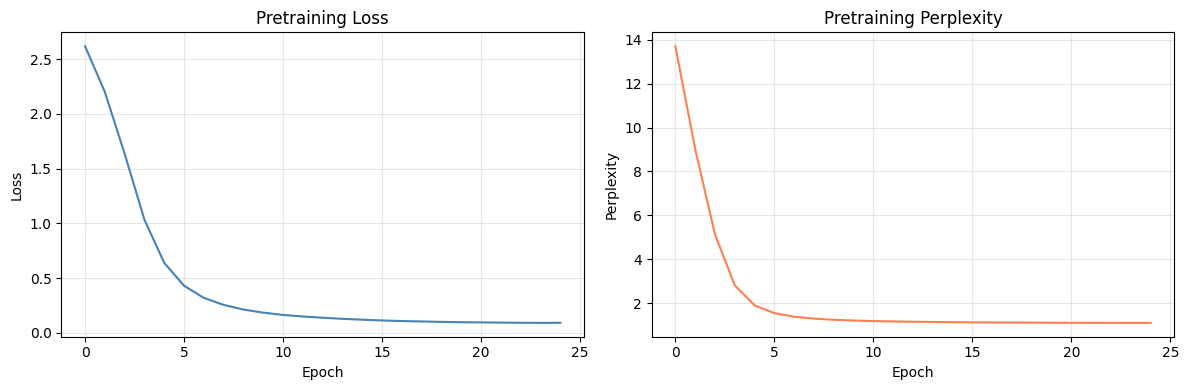

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(pt_losses, color='steelblue')
axes[0].set_title('Pretraining Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.3)
axes[1].plot(pt_ppls, color='coral')
axes[1].set_title('Pretraining Perplexity')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Perplexity')
axes[1].grid(alpha=0.3)
plt.tight_layout()
os.makedirs('results/plots', exist_ok=True)
plt.savefig('results/plots/pretrain_curves.png', dpi=150)
plt.show()

## Pretrained Model - Generation Examples

In [ ]:
def run_generation(prompt_text, max_new=80, temp=0.85, k=40):
    model.eval()
    ids = encode(prompt_text, add_bos_eos=True)
    x   = torch.tensor([ids], dtype=torch.long, device=DEVICE)
    out = model.generate(x, max_new=max_new, temp=temp, top_k=k)
    result = decode(out[0].tolist())
    # strip prompt from output
    if result.startswith(prompt_text):
        result = result[len(prompt_text):]
    return result.strip()


test_prompts = [
    'كان يا ما كان في قديم الزمان',
    'في يوم من الأيام جاء رجل غريب',
    'قال الحكيم العجوز لتلاميذه'
]

os.makedirs('results/sample_generations', exist_ok=True)
pretrain_gens = []

print('pretrained model outputs:')
print('-' * 50)
for p in test_prompts:
    g = run_generation(p)
    pretrain_gens.append({'prompt': p, 'generated': p + g})
    print(f'prompt: {p}')
    print(f'output: {(p+g)[:100]}')
    print()

with open('results/sample_generations/pretrain_stories_generations.json', 'w', encoding='utf-8') as f:
    json.dump(pretrain_gens, f, ensure_ascii=False, indent=2)

pretrained model outputs:
--------------------------------------------------
prompt: كان يا ما كان في قديم الزمان
output: كان يا ما كان في قديم الزمانفي الساء، جلس الملك وحاشيته للاستماع إلى حكايات الرجل العجيب.
بدأ الحكيم

prompt: في يوم من الأيام جاء رجل غريب
output: في يوم من الأيام جاء رجل غريبيحمل على ظهره حقيبة مليئة بالكتب والمخطوطات. وقف أمام بوابة القصر وطلب 

prompt: قال الحكيم العجوز لتلاميذه
output: قال الحكيم العجوز لتلاميذهالطفي بعد أنه الحاث و صندوق.
جاء يوم أصيب فيه الشيخ بمرض مفاجئ وغدا عاجزاً



## Phase 2 - Supervised Fine-Tuning

In [ ]:
class InstructionDataset(Dataset):
    def __init__(self, data, seq_len):
        self.seq_len = seq_len
        self.samples = []
        for item in data:
            # format: BOS + instruction + SEP + response + EOS
            if item['input'].strip():
                prompt_text = item['instruction'] + '\n' + item['input']
            else:
                prompt_text = item['instruction']
            full = [ch2id['<BOS>']] + encode(prompt_text) + [ch2id['<SEP>']] + encode(item['output']) + [ch2id['<EOS>']]
            if len(full) > seq_len + 1:
                full = full[:seq_len + 1]
            else:
                full += [ch2id['<PAD>']] * (seq_len + 1 - len(full))
            self.samples.append(torch.tensor(full, dtype=torch.long))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        s = self.samples[i]
        return s[:-1], s[1:]


LR_SFT    = 8e-5
EPOCHS_SFT = 15
BATCH_SFT  = 8

ds_sft = InstructionDataset(FINETUNE_DATA, SEQ_LEN)
dl_sft = DataLoader(ds_sft, batch_size=BATCH_SFT, shuffle=True)

opt_sft = torch.optim.AdamW(model.parameters(), lr=LR_SFT, weight_decay=0.01)
sch_sft = torch.optim.lr_scheduler.CosineAnnealingLR(opt_sft, T_max=EPOCHS_SFT)

print(f'fine-tuning on {len(ds_sft)} samples for {EPOCHS_SFT} epochs')

fine-tuning on 60 samples for 15 epochs


In [ ]:
sft_losses = []
sft_ppls   = []
t0 = time.time()

for epoch in range(1, EPOCHS_SFT + 1):
    model.train()
    total_loss = 0
    steps = 0

    for xb, yb in dl_sft:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt_sft.zero_grad()
        _, loss = model(xb, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt_sft.step()
        total_loss += loss.item()
        steps += 1

    sch_sft.step()
    avg = total_loss / max(steps, 1)
    ppl = math.exp(min(avg, 100))
    sft_losses.append(avg)
    sft_ppls.append(ppl)

    if epoch % 5 == 0 or epoch == 1:
        print(f'epoch {epoch}/{EPOCHS_SFT}  loss={avg:.4f}  ppl={ppl:.2f}  time={time.time()-t0:.0f}s')

os.makedirs('checkpoints/finetuned', exist_ok=True)
torch.save(model.state_dict(), 'checkpoints/finetuned/model.pt')
print('fine-tuned model saved')

epoch 1/15  loss=4.1829  ppl=65.56  time=0s
epoch 5/15  loss=2.3404  ppl=10.39  time=1s
epoch 10/15  loss=2.1499  ppl=8.58  time=3s
epoch 15/15  loss=2.1163  ppl=8.30  time=5s
fine-tuned model saved


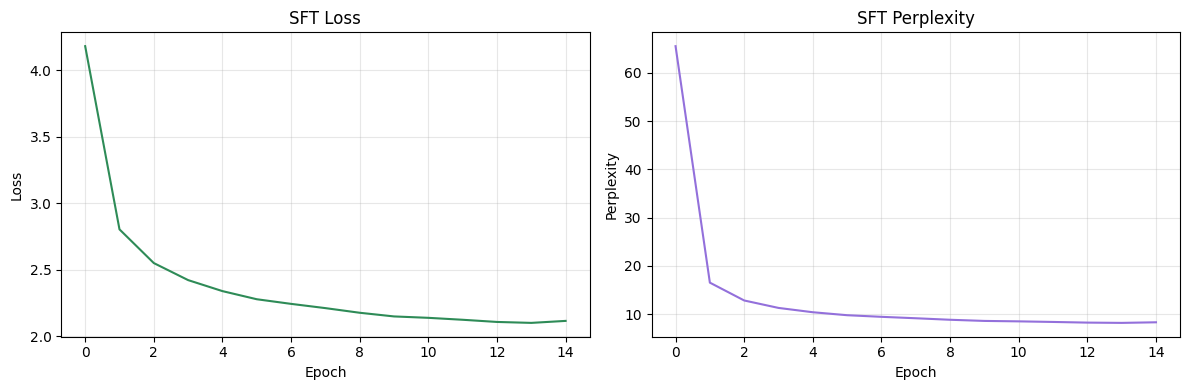

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(sft_losses, color='seagreen')
axes[0].set_title('SFT Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.3)
axes[1].plot(sft_ppls, color='mediumpurple')
axes[1].set_title('SFT Perplexity')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Perplexity')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('results/plots/sft_curves.png', dpi=150)
plt.show()

## Fine-tuned Model Demo

In [ ]:
def answer_instruction(instruction, context='', max_new=120, temp=0.75):
    model.eval()
    if context.strip():
        text = instruction + '\n' + context
    else:
        text = instruction
    ids = [ch2id['<BOS>']] + encode(text) + [ch2id['<SEP>']]
    x   = torch.tensor([ids], dtype=torch.long, device=DEVICE)
    out = model.generate(x, max_new=max_new, temp=temp, top_k=50)
    # get only the part after the last SEP token
    tokens = out[0].tolist()
    sep_id = ch2id['<SEP>']
    if sep_id in tokens:
        last_sep = len(tokens) - 1 - tokens[::-1].index(sep_id)
        response_tokens = tokens[last_sep + 1:]
    else:
        response_tokens = tokens[len(ids):]
    return decode(response_tokens)


test_cases = [
    ('اكتب قصة قصيرة عن الشجاعة', ''),
    ('اكتب نهاية لهذه القصة', 'وجد الصياد في شباكه سمكة ذهبية تتكلم'),
    ('ما الدرس المستفاد من هذه القصة', 'الراعي الذي كذب على قريته فلما جاء الذئب لم يصدقه أحد'),
    ('اكتب وصفاً لشخصية بطل القصة', 'رجل حكيم في الخمسين من عمره'),
    ('اكتب قصة عن التعاون', ''),
]

sft_gens = []
print('fine-tuned model outputs:')
print('-' * 50)
for inst, ctx in test_cases:
    resp = answer_instruction(inst, ctx)
    sft_gens.append({'instruction': inst, 'input': ctx, 'response': resp})
    print(f'instruction: {inst}')
    if ctx:
        print(f'input: {ctx}')
    print(f'response: {resp[:120]}')
    print()

with open('results/sample_generations/sft_stories_generations.json', 'w', encoding='utf-8') as f:
    json.dump(sft_gens, f, ensure_ascii=False, indent=2)

fine-tuned model outputs:
--------------------------------------------------
instruction: اكتب قصة قصيرة عن الشجاعة
response: كان في الذجد الغيرة الغني اسدوق أنه الحفي بح الأارطل العلم تعنه.
قال الملاب بعد من يها والعا لطريص البن اللحاراً من الم 

instruction: اكتب نهاية لهذه القصة
input: وجد الصياد في شباكه سمكة ذهبية تتكلم
response: قال أكن قابيل منه أنه الشار تلعي اليد الدني في بحر لحول عداً من السفكره تأحم وده لم رساء والأت. كانت الم وحراً مطف الأس 

instruction: ما الدرس المستفاد من هذه القصة
input: الراعي الذي كذب على قريته فلما جاء الذئب لم يصدقه أحد
response: قالكان حفي الم يوأحم ر نيفي الصاء الأراء. لأجد إليه من الة تبعين والمة لم والأفتان الفتق. جوملة بعد من الغ. كانت تبقاره 

instruction: اكتب وصفاً لشخصية بطل القصة
input: رجل حكيم في الخمسين من عمره
response: روح في أدينة صغير سقه الجب قدينة فتح البلشضير في شعامد. كن الأهوم الما الب يعراد ولن صتلعر فاسمه فمن وأأة سططته منال ير 

instruction: اكتب قصة عن التعاون
response: في الدينة يتجوم الطفيدة وجد رمده الطوم. كان الغريق ال

## Evaluation - Perplexity and Error Analysis

In [ ]:
@torch.no_grad()
def get_perplexity(dataloader):
    model.eval()
    total, count = 0.0, 0
    for xb, yb in dataloader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        _, loss = model(xb, yb)
        total += loss.item()
        count += 1
    avg = total / max(count, 1)
    return avg, math.exp(min(avg, 100))


loss_pt, ppl_pt = get_perplexity(dl_pretrain)
loss_sft, ppl_sft = get_perplexity(dl_sft)

print('evaluation results')
print(f'  pretraining set:  loss={loss_pt:.4f}  ppl={ppl_pt:.2f}')
print(f'  fine-tuning set:  loss={loss_sft:.4f}  ppl={ppl_sft:.2f}')

evaluation results
  pretraining set:  loss=0.6815  ppl=1.98
  fine-tuning set:  loss=1.9303  ppl=6.89


In [ ]:
# error analysis on edge cases
error_cases = [
    {'instruction': 'اكتب قصة طويلة جداً عن رحلة عبر الصحراء', 'input': '', 'type': 'long output request'},
    {'instruction': 'اكتب', 'input': '', 'type': 'very short instruction'},
    {'instruction': 'اكتب قصة عن موضوع غير مألوف في التدريب', 'input': '', 'type': 'out of distribution'},
]

errors = []
print('error analysis')
print('-' * 50)
for case in error_cases:
    resp = answer_instruction(case['instruction'], case['input'], max_new=100, temp=0.9)
    problems = []
    if len(resp) < 10:
        problems.append('response too short')
    arabic_ratio = sum(1 for c in resp if '\u0600' <= c <= '\u06ff') / max(len(resp), 1)
    if arabic_ratio < 0.4:
        problems.append('low arabic character ratio')
    if resp.count('\n') > 10:
        problems.append('too many newlines')
    if not problems:
        problems.append('no issues found')
    errors.append({'type': case['type'], 'instruction': case['instruction'], 'response': resp[:80], 'problems': problems})
    print(f'case: {case["type"]}')
    print(f'response: {resp[:80]}')
    print(f'issues: {problems}')
    print()

with open('results/error_analysis.json', 'w', encoding='utf-8') as f:
    json.dump(errors, f, ensure_ascii=False, indent=2)

error analysis
--------------------------------------------------
case: long output request
response: في ملوقه ب فقصة الصيراً. لسدسغره الاذية وقيوم اللأسته كلد يغا مفي ه. تقالي هذن ا
issues: ['no issues found']

case: very short instruction
response:  قصة عن القصة والكبيرح طلرار عن يالدب وأس. أنول مج ما بعد شاسن: الد أنيق. بعد أن
issues: ['no issues found']

case: out of distribution
response: كان وح قديمه خلة يموجاً يتخيم رحوم، جحال أته هذا صدوق، فترة الأحمل عجوز يرف ننال
issues: ['no issues found']



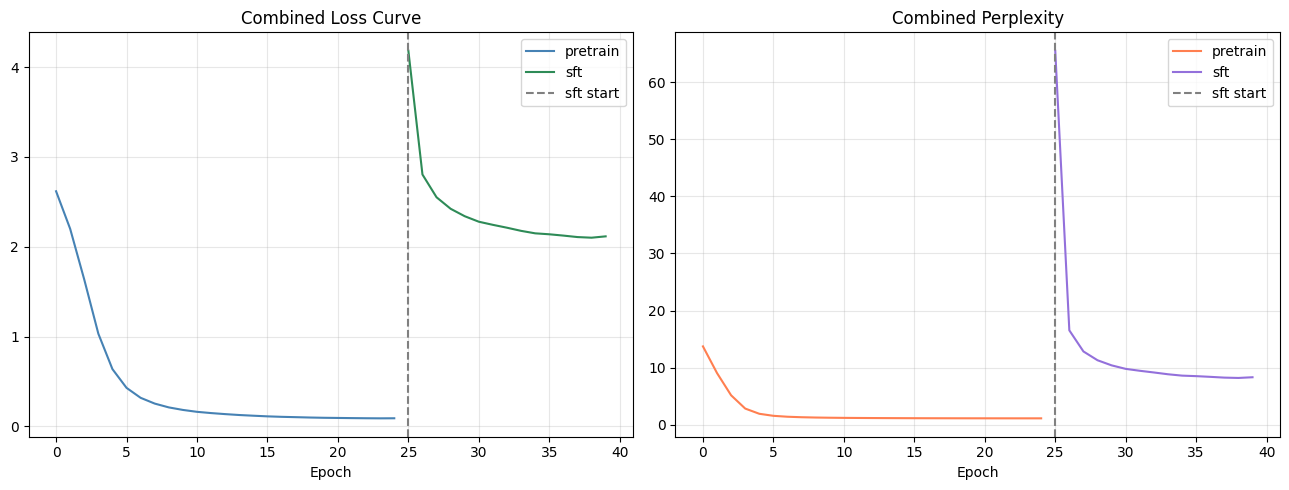

In [ ]:
# combined training curve
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x_sft = list(range(EPOCHS_PRETRAIN, EPOCHS_PRETRAIN + EPOCHS_SFT))

axes[0].plot(pt_losses, label='pretrain', color='steelblue')
axes[0].plot(x_sft, sft_losses, label='sft', color='seagreen')
axes[0].axvline(x=EPOCHS_PRETRAIN, color='gray', linestyle='dashed', label='sft start')
axes[0].set_title('Combined Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(pt_ppls, label='pretrain', color='coral')
axes[1].plot(x_sft, sft_ppls, label='sft', color='mediumpurple')
axes[1].axvline(x=EPOCHS_PRETRAIN, color='gray', linestyle='dashed', label='sft start')
axes[1].set_title('Combined Perplexity')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/plots/combined_training_curves.png', dpi=150)
plt.show()

## Summary

In [ ]:
summary = {
    'project': 'Arabic Stories GPT from Scratch',
    'model': {
        'class': 'StoryGPT',
        'vocab_size': VOCAB_SIZE,
        'd_model': D_MODEL,
        'n_heads': N_HEADS,
        'n_layers': N_LAYERS,
        'd_ff': D_FF,
        'total_params': sum(p.numel() for p in model.parameters())
    },
    'data': {
        'pretrain_lines': len(PRETRAIN_TEXT.split('\n')),
        'finetune_samples': len(FINETUNE_DATA),
        'language': 'Arabic'
    },
    'results': {
        'pretrain_loss': round(pt_losses[-1], 4),
        'pretrain_ppl': round(pt_ppls[-1], 2),
        'sft_loss': round(sft_losses[-1], 4),
        'sft_ppl': round(sft_ppls[-1], 2)
    }
}

with open('results/final_report.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print('project summary')
print(f'  model params   : {summary["model"]["total_params"]:,}')
print(f'  vocab size     : {summary["model"]["vocab_size"]}')
print(f'  pretrain lines : {summary["data"]["pretrain_lines"]}')
print(f'  sft samples    : {summary["data"]["finetune_samples"]}')
print(f'  pretrain ppl   : {summary["results"]["pretrain_ppl"]}')
print(f'  sft ppl        : {summary["results"]["sft_ppl"]}')
print('all files saved')

project summary
  model params   : 1,811,904
  vocab size     : 51
  pretrain lines : 30
  sft samples    : 60
  pretrain ppl   : 1.1
  sft ppl        : 8.3
all files saved


## Done

The notebook trained a GPT model from scratch on Arabic stories in two phases. Pretraining taught the model Arabic language patterns through next token prediction. Fine-tuning adapted it to follow story writing instructions. Results and checkpoints are saved in the results and checkpoints folders.